<a href="https://colab.research.google.com/github/penajuanmanuel6-hub/automated-etl-pipeline/blob/main/modelado_resiliencia_hidrica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Resumen Analítico de Recursos Hídricos ---
           estacion  total_registros  prom_precipitacion  prom_caudal  \
0  Estación Central              158               15.32        24.21   
1      Estación Sur              162               16.37        24.19   
2    Estación Norte              180               14.73        23.22   

   caudal_maximo  
0          44.33  
1          44.81  
2          44.67  


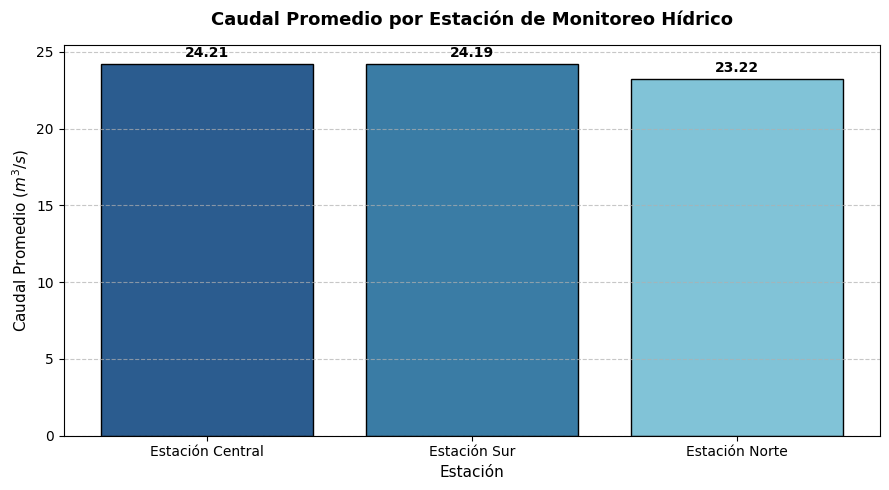

In [1]:
#Proyecto 1: Gestión Integral de Recursos Hídricos y Modelado de Resiliencia

import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. CONFIGURACIÓN Y CONEXIÓN
# ==========================================
DB_NAME = "recursos_hidricos.db"


def crear_conexion():
  """Establece y retorna la conexión a la base de datos SQLite."""
  return sqlite3.connect(DB_NAME)


# ==========================================
# 2. EXTRACCIÓN (Simulación e Ingesta inicial)
# ==========================================
def extraer_datos_hidricos():
  """Genera y extrae los datos brutos de las estaciones hidrometeorológicas."""
  np.random.seed(42)
  fechas = pd.date_range(start="2025-01-01", periods=180, freq="D")
  estaciones = ["Estación Norte", "Estación Sur", "Estación Central"]

  datos_brutos = pd.DataFrame(
      {
          "fecha": np.random.choice(fechas, 500),
          "estacion": np.random.choice(estaciones, 500),
          "precipitacion_mm": np.random.exponential(scale=15, size=500).round(2),
          "caudal_m3s": np.random.uniform(2.5, 45.0, 500).round(2),
      }
  )

  conn = crear_conexion()
  datos_brutos.to_sql("monitoreo_hidrico", conn, if_exists="replace", index=False)
  conn.close()
  return "Datos hidricos cargados exitosamente."


# ==========================================
# 3. TRANSFORMACIÓN Y CARGA (Procesamiento SQL)
# ==========================================
def transformar_y_consultar():
  """Ejecuta consultas analíticas y transformaciones en la base de datos."""
  conn = crear_conexion()
  query = """
        SELECT
            estacion,
            COUNT(fecha) AS total_registros,
            ROUND(AVG(precipitacion_mm), 2) AS prom_precipitacion,
            ROUND(AVG(caudal_m3s), 2) AS prom_caudal,
            ROUND(MAX(caudal_m3s), 2) AS caudal_maximo
        FROM monitoreo_hidrico
        GROUP BY estacion
        ORDER BY prom_caudal DESC;
    """
  df_resultado = pd.read_sql(query, conn)
  conn.close()
  return df_resultado


# ==========================================
# 4. VISUALIZACIÓN DE RESULTADOS
# ==========================================
def visualizar_resultados(df):
  """Genera el gráfico de barras con los caudales promedio."""
  fig, ax = plt.subplots(figsize=(9, 5))
  barras = ax.bar(
      df["estacion"],
      df["prom_caudal"],
      color=["#2b5c8f", "#3a7ca5", "#81c3d7"],
      edgecolor="black",
  )

  ax.set_title(
      "Caudal Promedio por Estación de Monitoreo Hídrico",
      fontsize=13,
      fontweight="bold",
      pad=15,
  )
  ax.set_xlabel("Estación", fontsize=11)
  ax.set_ylabel("Caudal Promedio ($m^3/s$)", fontsize=11)
  ax.grid(axis="y", linestyle="--", alpha=0.7)

  for barra in barras:
    altura = barra.get_height()
    ax.annotate(
        f"{altura}",
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

  plt.tight_layout()
  plt.show()


# Ejecución del pipeline
extraer_datos_hidricos()
df_hidrico = transformar_y_consultar()
print("--- Resumen Analítico de Recursos Hídricos ---")
print(df_hidrico)
visualizar_resultados(df_hidrico)